In [1]:
import logging
from IPython.display import Markdown, display

import scarf
from scarf import cytebase

scarf.configure_output(level="WARNING", progress=False)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
catalog = cytebase.Catalog()  # Public Cytebase unless CYTEBASE_BUCKET is set.

In [2]:
matches = catalog.search("wilson kidney cortex")
if not matches:
    raise RuntimeError("The example kidney dataset is not ready in this bucket")
match_preview = matches.to_markdown(
    columns=["cytebase_id", "title", "cell_count"], max_cell_chars=32
)
display(Markdown(match_preview))

| Cytebase ID | Title | Cells |
| --- | --- | ---: |
| wilson&#95;2022&#95;human&#95;kidney&#95;cortex… | Human kidney cortex snRNA-seq d… | 39,176 |

1 row. Long cells are shortened; use `max_cell_chars=None` to display complete values. Row dictionaries retain the full values.

In [3]:
dataset_id = matches[0]["cytebase_id"]
entry = catalog.dataset(dataset_id)
entry

### Human kidney cortex snRNA-seq data from donors with and without diabetic kidney disease

- **Cytebase ID:** `wilson_2022_human_kidney_cortex_snrna_diabetic_kidney_disease_e067e5ca`
- **Citation:**
    - Publication: https://doi.org/10.1038/s41467-022-32972-z
    - Dataset Version: https://datasets.cellxgene.cziscience.com/473d2e1c-a579-4682-96aa-b5b166d7b23e.h5ad
    - curated and distributed by CZ CELLxGENE Discover in Collection: https://cellxgene.cziscience.com/collections/b3e2c6e3-9b05-4da9-8f42-da38a664b45b
- **DOI:** 10.1038/s41467-022-32972-z
- **CELLxGENE:** https://cellxgene.cziscience.com/collections/b3e2c6e3-9b05-4da9-8f42-da38a664b45b
- **Explorer:** https://cellxgene.cziscience.com/e/e067e5ca-e53e-485f-aa8e-efd5435229c8.cxg/
- **Size:** 39,176 cells, 35,469 genes
- **Status:** ready
- **Organisms:** Homo sapiens
- **Assays:** 10x 3' v3, 10x 5' v1
- **Tissues:** cortex of kidney
- **Diseases:** normal, type 2 diabetes mellitus
- **Suspension:** nucleus
- **Source embeddings:** X_harmony, X_pca, X_umap

In [4]:
ds = catalog.open_datastore(entry.id)
ds

DataStore has 39176 (39176) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_nCounts', 'RNA_nFeatures', 
            'RNA_percentMito', 'RNA_percentRibo', 'assay', 'assay_ontology_term_id', 'author_cell_type', 
            'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 
            'disease_ontology_term_id', 'donor_id', 'doublet_id', 'is_primary_data', 'library_uuid', 
            'mapped_reference_annotation', 'nCount_RNA', 'nCount_SCT', 'nFeature_RNA', 'nFeature_SCT', 
            'observation_joinid', 'percent.mt', 'percent.rpl', 'percent.rps', 'reported_diseases', 
            'sample_preservation_method', 'sample_uuid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'seurat_clusters', 
            'sex', 'sex_ontology_term_id', 'suspension_type', 'suspension_uuid', 'tissue', 
            'tissue_ontology_term_id', 'tissue_type'
   RNA assay has 35469 features 

In [5]:
print("Source embedding keys:", entry.source_embeddings())
print("Imported embedding keys:", sorted(cytebase.embeddings(ds)))
umap_ref = cytebase.embedding(ds, "X_umap")

Source embedding keys: ['X_harmony', 'X_pca', 'X_umap']


Imported embedding keys: ['X_umap']


In [6]:
import pandas as pd

wanted = ["cell_type", "tissue", "disease", "donor_id", "sex", "assay"]
columns = [column for column in wanted if column in ds.cells.columns]
meta = ds.cells.to_pandas_dataframe(["ids", *columns], key="I").set_index("ids")
with pd.option_context("display.max_colwidth", None):
    display(meta[["cell_type", "disease", "donor_id"]].head())

,cell_type,disease,donor_id
ids,,,
AAACCTGAGTGTTAGA-1,epithelial cell of proximal tubule,normal,control_1
AAACCTGCAAGCGCTC-1,kidney loop of Henle thick ascending limb epithelial cell,normal,control_1
AAACCTGCACCAGATT-1,kidney loop of Henle thick ascending limb epithelial cell,normal,control_1
AAACCTGCAGTCAGAG-1,epithelial cell of proximal tubule,normal,control_1
AAACCTGCATGGAATA-1,kidney distal convoluted tubule epithelial cell,normal,control_1


In [7]:
meta["cell_type"].value_counts().rename("cells").to_frame()

,cells
cell_type,
epithelial cell of proximal tubule,11478
kidney distal convoluted tubule epithelial cell,8469
kidney loop of Henle thick ascending limb epithelial cell,7749
renal principal cell,3295
renal alpha-intercalated cell,2029
endothelial cell,1702
parietal epithelial cell,1103
podocyte,1069
kidney loop of Henle thin ascending limb epithelial cell,679


In [8]:
pd.crosstab(meta["cell_type"], meta["disease"])

disease,normal,type 2 diabetes mellitus
cell_type,,
endothelial cell,1167,535
epithelial cell of proximal tubule,8818,2660
fibroblast,210,128
kidney distal convoluted tubule epithelial cell,6099,2370
kidney loop of Henle thick ascending limb epithelial cell,5432,2317
kidney loop of Henle thin ascending limb epithelial cell,324,355
leukocyte,54,156
mesangial cell,268,117
parietal epithelial cell,696,407


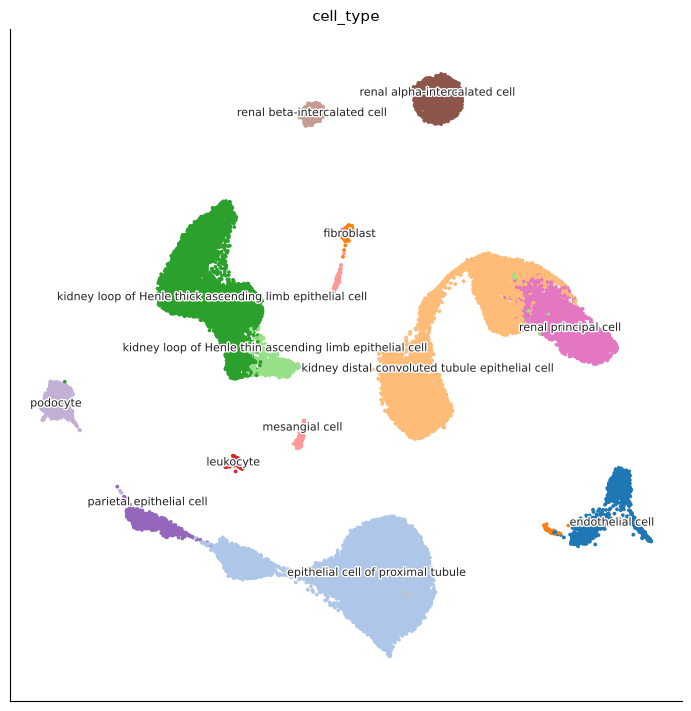

In [9]:
cell_type_plot = ds.plots.embedding(
    layout=umap_ref, color_by="cell_type", figsize=(10, 7)
)

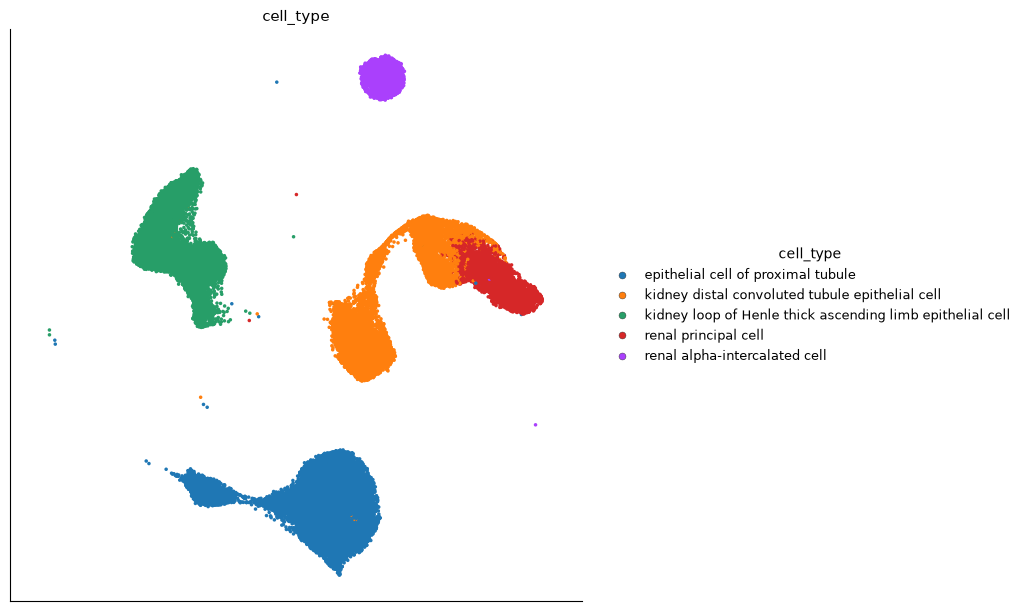

In [10]:
top_types = meta["cell_type"].value_counts().head(5).index.tolist()
ds.plots.embedding(
    layout=umap_ref,
    color_by="cell_type",
    groups=top_types,
    figsize=(10, 6),
)

In [11]:
genes = ["UMOD", "SLC34A1", "NPHS1", "PECAM1"]

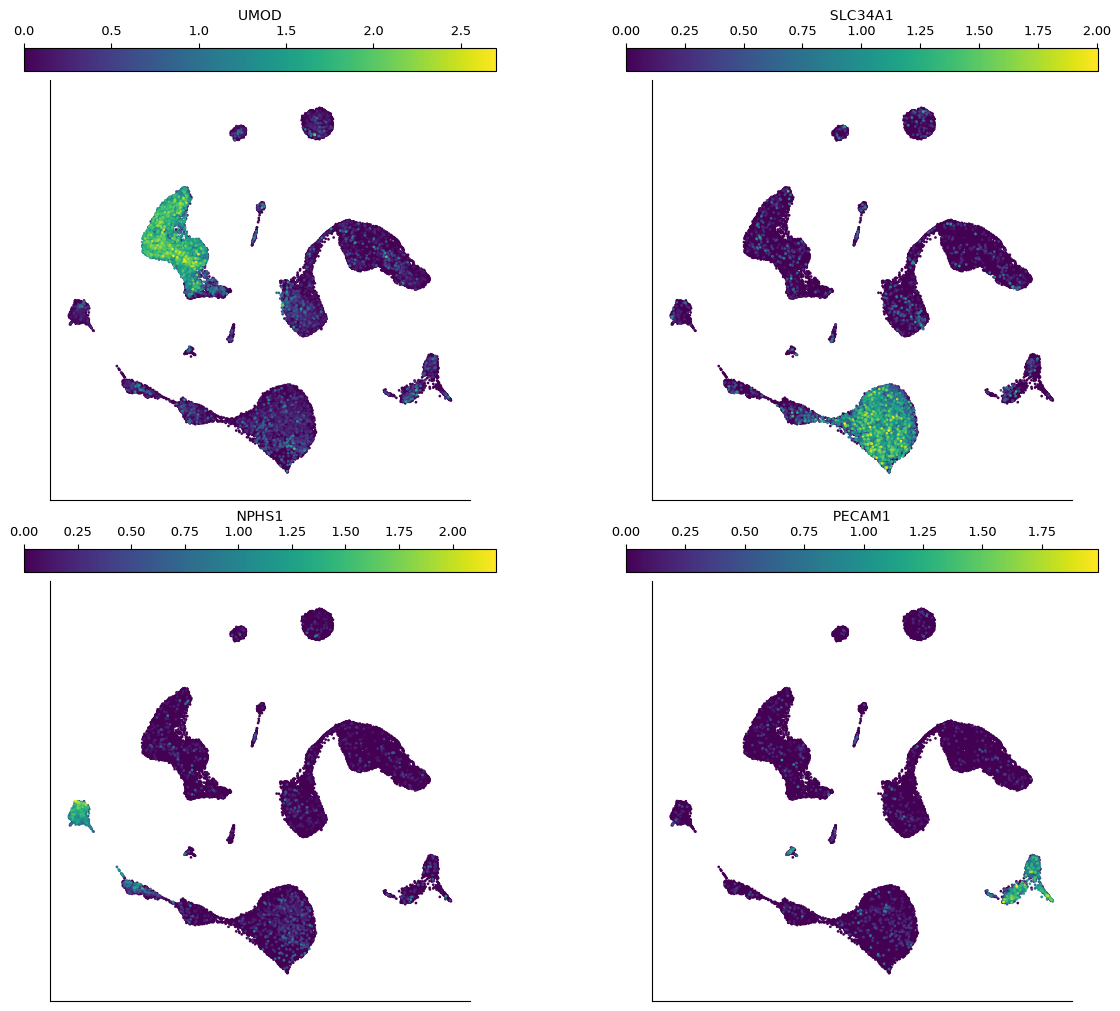

In [12]:
from scarf.plotting import NormalizationSpec

ds.plots.embedding(
    layout=umap_ref,
    color_by=genes,
    normalization=NormalizationSpec(transform="log1p"),
    sort_values=True,
    n_columns=2,
    figsize=(12, 10),
)

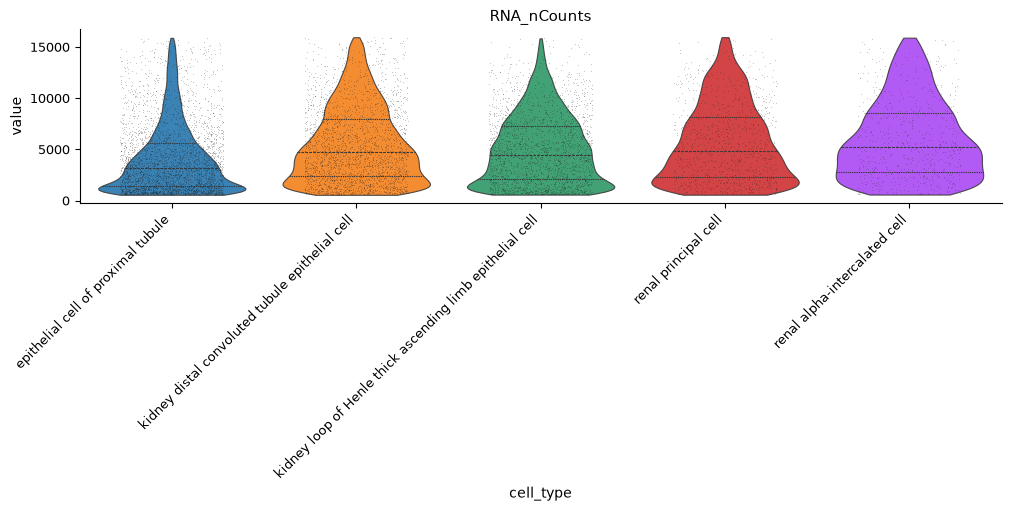

In [13]:
from scarf.plotting import CellField

ds.plots.distribution(
    "RNA_nCounts",
    grouping=CellField("cell_type"),
    groups=top_types,
    figsize=(10, 5),
)

In [14]:
coords = cytebase.embedding_coordinates(ds, umap_ref)
frame = coords.join(meta)
with pd.option_context("display.max_colwidth", None):
    display(frame[["umap_1", "umap_2", "cell_type"]].head())

,umap_1,umap_2,cell_type
ids,,,
AAACCTGAGTGTTAGA-1,-0.523972,-8.470732,epithelial cell of proximal tubule
AAACCTGCAAGCGCTC-1,-7.073731,3.068685,kidney loop of Henle thick ascending limb epithelial cell
AAACCTGCACCAGATT-1,-6.279858,4.984632,kidney loop of Henle thick ascending limb epithelial cell
AAACCTGCAGTCAGAG-1,0.838804,-11.116598,epithelial cell of proximal tubule
AAACCTGCATGGAATA-1,3.573810,5.386316,kidney distal convoluted tubule epithelial cell


In [15]:
from pathlib import Path

out = Path("figures")
out.mkdir(exist_ok=True)
cell_type_plot.save(out / "cytebase_cell_types.png", dpi=150)
cell_type_plot.close()
print("Saved figures/cytebase_cell_types.png")

Saved figures/cytebase_cell_types.png


In [16]:
catalog.list_terms("disease")

| Label | Ontology ID | Datasets |
| --- | --- | ---: |
| Alzheimer disease | MONDO:0004975 | 9 |
| B-cell acute lymphoblastic leukemia | MONDO:0004947 | 2 |
| B-cell non-Hodgkin lymphoma | MONDO:0015759 | 3 |
| Barrett esophagus | MONDO:0013662 | 1 |
| COVID-19 | MONDO:0100096 | 54 |
| Crohn disease | MONDO:0005011 | 11 |
| DMD-related muscular dystrophy | MONDO:0700285 | 8 |
| Down syndrome | MONDO:0008608 | 1 |
| Ewing sarcoma | MONDO:0012817 | 1 |
| HER2 positive breast carcinoma | MONDO:0006244 | 5 |
| HIV infectious disease | MONDO:0005109 | 1 |
| HIV infectious disease &#124;&#124; leishmaniasis | MONDO:0005109 &#124;&#124; MONDO:0011989 | 1 |
| HIV infectious disease &#124;&#124; visceral leishmaniasis | MONDO:0005109 &#124;&#124; MONDO:0005445 | 2 |
| Lewy body dementia | MONDO:0007488 | 8 |
| Parkinson disease | MONDO:0005180 | 10 |
| Pick disease | MONDO:0008243 | 1 |
| Plasmodium malariae malaria | MONDO:0001943 | 1 |
| Sjogren syndrome | MONDO:0010030 | 12 |
| T-cell childhood acute lymphocytic leukemia | MONDO:0000871 | 2 |
| Wilms tumor | MONDO:0006058 | 1 |

Showing 20 of 322 rows. Use `to_markdown(max_rows=None)` to display all rows.

In [17]:
tissue = matches[0]["tissue_labels"][0]
kidney_datasets = catalog.find_datasets(tissue=tissue, organism="Homo sapiens")
kidney_preview = kidney_datasets.to_markdown(
    columns=["cytebase_id", "cell_count", "disease_labels"], max_cell_chars=32
)
display(Markdown(kidney_preview))

| Cytebase ID | Cells | Diseases |
| --- | ---: | --- |
| lake&#95;2025&#95;single&#95;nucleus&#95;rna&#95;se… | 1,388,643 | acute kidney injury, chronic ki… |
| tabula&#95;2022&#95;tabula&#95;sapiens&#95;all&#95;… | 1,136,218 | normal |
| aceramateos&#95;2025&#95;multimodal&#95;ben… | 97,125 | normal |
| marshall&#95;2022&#95;spatial&#95;transcrip… | 40,436 | normal |
| stewart&#95;2019&#95;mature&#95;kidney&#95;data… | 40,268 | normal |
| wilson&#95;2022&#95;human&#95;kidney&#95;cortex… | 39,176 | normal, type 2 diabetes mellitus |
| marshall&#95;2022&#95;spatial&#95;transcrip… | 38,024 | normal |
| aceramateos&#95;2025&#95;multimodal&#95;ben… | 37,717 | normal |
| marshall&#95;2022&#95;spatial&#95;transcrip… | 29,921 | normal |
| marshall&#95;2022&#95;spatial&#95;transcrip… | 29,769 | normal |
| marshall&#95;2022&#95;spatial&#95;transcrip… | 28,422 | normal |
| mcevoy&#95;2022&#95;living&#95;donor&#95;kidney… | 27,675 | normal |
| marshall&#95;2022&#95;spatial&#95;transcrip… | 27,036 | normal |
| marshall&#95;2022&#95;spatial&#95;transcrip… | 25,741 | normal |
| marshall&#95;2022&#95;spatial&#95;transcrip… | 25,166 | normal |
| marshall&#95;2022&#95;spatial&#95;transcrip… | 23,857 | normal |
| marshall&#95;2022&#95;spatial&#95;transcrip… | 23,510 | normal |
| marshall&#95;2022&#95;spatial&#95;transcrip… | 23,145 | normal |
| marshall&#95;2022&#95;spatial&#95;transcrip… | 20,245 | normal |
| muto&#95;2021&#95;single&#95;cell&#95;transcrip… | 19,985 | normal |

Showing 20 of 30 rows. Use `to_markdown(max_rows=None)` to display all rows. Long cells are shortened; use `max_cell_chars=None` to display complete values. Row dictionaries retain the full values.

In [18]:
small_datasets = catalog.query(
    """
    SELECT cytebase_id, first_author, year, cell_count, n_genes,
           len(cell_type_labels) AS n_cell_types
    FROM datasets
    WHERE status = ? AND processed_version_id = latest_version_id
      AND zarr_uri IS NOT NULL
    ORDER BY cell_count
    LIMIT 10
    """,
    parameters=["ready"],
)
display(Markdown(small_datasets.to_markdown(max_cell_chars=24)))

| Cytebase ID | First Author | Year | Cells | Genes | N Cell Types |
| --- | --- | ---: | ---: | ---: | --- |
| johansen&#95;2023&#95;sstchodl&#95;… | Johansen | 2,023 | 301 | 18,736 | 1 |
| ng&#95;2026&#95;t&#95;cells&#95;small&#95;c… | Ng | 2,026 | 450 | 13,943 | 1 |
| sampath&#95;kumar&#95;2023&#95;mous… | Sampath Kumar | 2,023 | 499 | 18,877 | 2 |
| johansen&#95;2023&#95;l5et&#95;neoc… | Johansen | 2,023 | 563 | 18,736 | 1 |
| johansen&#95;2023&#95;endo&#95;neoc… | Johansen | 2,023 | 582 | 18,736 | 1 |
| johansen&#95;2023&#95;vlmc&#95;neoc… | Johansen | 2,023 | 637 | 18,736 | 1 |
| sampath&#95;kumar&#95;2023&#95;mous… | Sampath Kumar | 2,023 | 703 | 27,368 | 16 |
| duclos&#95;2019&#95;characteriz… | Duclos | 2,019 | 796 | 51,976 | 9 |
| szabo&#95;2021&#95;74&#95;years&#95;old… | Szabo | 2,021 | 810 | 32,393 | 8 |
| fujimoto&#95;2020&#95;mouse&#95;lym… | Fujimoto | 2,020 | 893 | 17,932 | 4 |

10 rows. Long cells are shortened; use `max_cell_chars=None` to display complete values. Row dictionaries retain the full values.